# Constrained Tikhonov regularization implemented by (accelerated) forward-backward splitting
We consider the two-dimensional deconvolution problems to find a non-negative function f given data 
$$
    d \sim \mathrm{Pois}(h*f)
$$
with a non-negative convolution kernel $h$, and $\mathrm{Pois}$ denotes the element-wise Poisson distribution.

We explore the use of the semismooth Newton method to implement constrained Tikhonov regularization 
$$
\hat{f} = \mathrm{argmin}_{f\geq 0} \left[\| h*f-d\|^2_{L^2(w)} + \alpha \|f\|^2_{L^2}\right]
$$
with a weight $w = \frac{1}{\sqrt{d+1}}$. The regularization parameter $\alpha$ is chosen by the discrepancy principle.   

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mplib
from regpy.operators import CoordinateMask 
from regpy.operators.convolution import ConvolutionOperator, GaussianBlur, ExponentialConvolution
from regpy.vecsps import UniformGridFcts
from regpy.solvers import TikhonovRegularizationSetting, RegularizationSetting, DualityGapStopping
from regpy.solvers.linear.semismoothNewton import SemismoothNewton_bilateral, SemismoothNewton_nonneg, SemismoothNewtonAlphaGrid
from regpy.solvers.linear.proximal_gradient import ForwardBackwardSplitting, FISTA
from regpy.solvers.linear.primal_dual import PDHG
from regpy.hilbert import L2, HmDomain
from regpy.stoprules import CountIterations, Discrepancy
from regpy.functionals import QuadraticLowerBound, QuadraticBilateralConstraints
import logging
from numpy.linalg import norm

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s %(levelname)s %(name)-20s :: %(message)s'
)

### plotting routine for comparing reconstructions and originals 

In [2]:
def comparison_plot(grid,truth,reco,title_right='exact',title_left='reconstruction',residual=None):
    plt.rcParams.update({'font.size': 22})
    extent = [grid.axes[0][0],grid.axes[0][-1], grid.axes[1][0], grid.axes[1][-1]]
    maxval = np.max(truth[:]); minval = np.min(truth[:])
    mycmap = mplib.colormaps['hot']
    mycmap.set_over((0,0,1.,1.))  # use blue as access color for large values
    mycmap.set_under((0,1,0,1.))  # use green as access color for small values
    if not (residual is None):
        fig, ((ax1,ax2),(ax3,ax4)) = plt.subplots(2,2,figsize = (22,16))
    else:
        fig, (ax1,ax2) = plt.subplots(1,2,figsize = (22,8))
    im1= ax1.imshow(reco.T,extent=extent,origin='lower',
                    vmin=1.05*minval-0.05*maxval, vmax =1.05*maxval-0.05*minval,
                    cmap=mycmap
                    )
    ax1.title.set_text(title_left)
    fig.colorbar(im1,extend='both')
    im2= ax2.imshow(truth.T,extent=extent, origin='lower',
                    vmin=1.05*minval-0.05*maxval, vmax =1.05*maxval-0.05*minval,
                    cmap=mycmap
                    )
    ax2.title.set_text(title_right)
    fig.colorbar(im2,extend='both',orientation='vertical')
    if not (residual is None):
        maxv = np.max(reco[:]-truth[:])
        im3 = ax3.imshow(truth.T-reco.T,extent=extent, origin='lower',vmin= -maxv,vmax=maxv,cmap='RdYlBu_r')
        ax3.title.set_text('reconstruction error')
        fig.colorbar(im3)

        maxv = np.max(residual[:])
        im4 = ax4.imshow(residual.T,extent=extent, origin='lower',vmin= -maxv,vmax=maxv,cmap='RdYlBu_r')
        ax4.title.set_text('data residual')
        fig.colorbar(im4)

### test objects

In [3]:
grid = UniformGridFcts((-1, 1, 256), (-1.5, 1, 256),dtype = float, periodic = True)
"""Space of real-valued functions on a uniform grid with rectangular pixels"""
X = grid.coords[0]; Y = grid.coords[1]
"""x and y coordinates."""
cross = 1.0*np.logical_or((abs(X)<0.01) * (abs(Y)<0.3),(abs(X)<0.3) * (abs(Y)<0.01)) 
rad = np.sqrt(X**2 + Y**2)
ring = 1.0*np.logical_and(rad>=0.9, rad<=0.95)
smallbox = (abs(X+0.55)<=0.05) * (abs(Y-0.55)<=0.05)
bubbles = (1.001+np.sin(50/(X+1.3)))*np.exp(-((Y+1.25)/0.1)**2)*(X>-0.8)*(X<0.8)

ramp = Y<=-1

objects = 200*(ring + 2.0*cross + 1.5*smallbox + 2*ramp -bubbles)
exact_sol = objects 


### creating Poisson distributed synthetic data

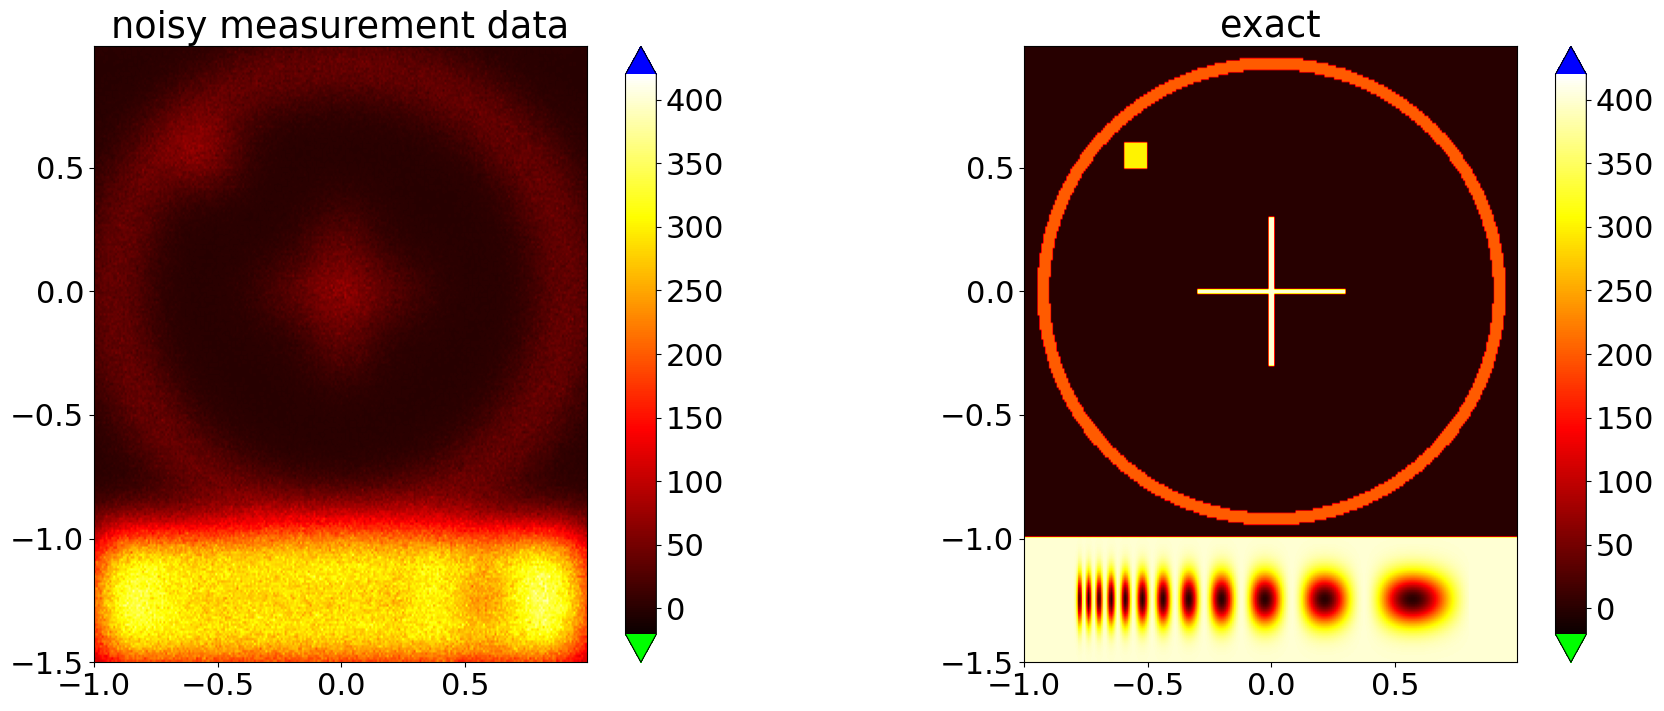

In [4]:
a=0.15
conv =  GaussianBlur(grid,a,pad_amount=((16,16),(16,16)))
"""Convolution operator \(f\mapsto h*f\) for the convolution kernel \(h(x)=\exp(-|x|_2^2/a^2)\)."""
blur = conv(exact_sol)
blur[blur<0] = 0.
"""Simulated exact data."""
data = np.random.poisson(blur)
"""Simulated measured data. The Poisson distribution occurs if photon count detectors are used."""
comparison_plot(grid,exact_sol,data,title_left='noisy measurement data')

In [5]:
weighted_data_space = L2(grid, weights = 1./(1.+data))
setting = RegularizationSetting(op=conv, penalty=L2, data_fid=weighted_data_space)
alpha = 0.001

SSNewton_nn = SemismoothNewton_nonneg(setting, data, alpha, TOL = 0.01, 
                                    logging_level=logging.DEBUG, cg_logging_level=logging.INFO)
it = iter(SSNewton_nn)

2024-07-06 22:23:57,905 INFO TikhonovCG           :: it.63 kappa=3.072081978466954 err/Tol abs X: 2.7e-02/3.2e-02
2024-07-06 22:23:57,906 INFO TikhonovCG           :: Solver converged after 63 iteration.
2024-07-06 22:23:57,910 DEBUG SemismoothNewton_nonneg :: it 0: CG its 63; changes active set +17085.0,-0


# Reconstructions with one sided constraints

In [6]:
penLower = QuadraticLowerBound(grid,x0=0,lb=0)
alpha = 1e-3
n_iter = 400 
settingLower = TikhonovRegularizationSetting(op=conv, penalty=penLower, data_fid = L2,data_fid_shift=data,regpar=alpha)

### Forward-backward splitting

In [7]:
FB_solver_lb = ForwardBackwardSplitting(settingLower)
stop_FB_lb=DualityGapStopping(FB_solver_lb,threshold = 1., max_iter=n_iter,logging_level=logging.WARNING)
FB_solver_lb.run(stoprule=stop_FB_lb)

comparison_plot(grid,exact_sol,x,title_left='Forward-backward')

AttributeError: 'numpy.float64' object has no attribute 'self'

### FISTA

2024-07-06 22:10:09,451 INFO FISTA                :: Setting up FISTA with convexity parameters mu_R=1.000e-03, mu_S=0.000e+00 and step length tau=1.042e+00.
 Expected linear convergence rate: 9.677e-01
2024-07-06 22:10:09,482 INFO FISTA                :: initial duality gap: 3.107e+10
2024-07-06 22:10:09,483 INFO DualityGapStopping   :: it. 0/400: duality gap=3.107e+10
2024-07-06 22:10:09,486 INFO DualityGapStopping   :: it. 0/400: duality gap=3.107e+10
2024-07-06 22:10:09,533 INFO FISTA                :: it.1: duality gap=1.183e+09
2024-07-06 22:10:09,534 INFO DualityGapStopping   :: it. 1/400: duality gap=1.183e+09
2024-07-06 22:10:09,571 INFO FISTA                :: it.2: duality gap=2.021e+08
2024-07-06 22:10:09,572 INFO DualityGapStopping   :: it. 2/400: duality gap=2.021e+08
2024-07-06 22:10:09,616 INFO FISTA                :: it.3: duality gap=2.446e+07
2024-07-06 22:10:09,617 INFO DualityGapStopping   :: it. 3/400: duality gap=2.446e+07
2024-07-06 22:10:09,654 INFO FISTA      

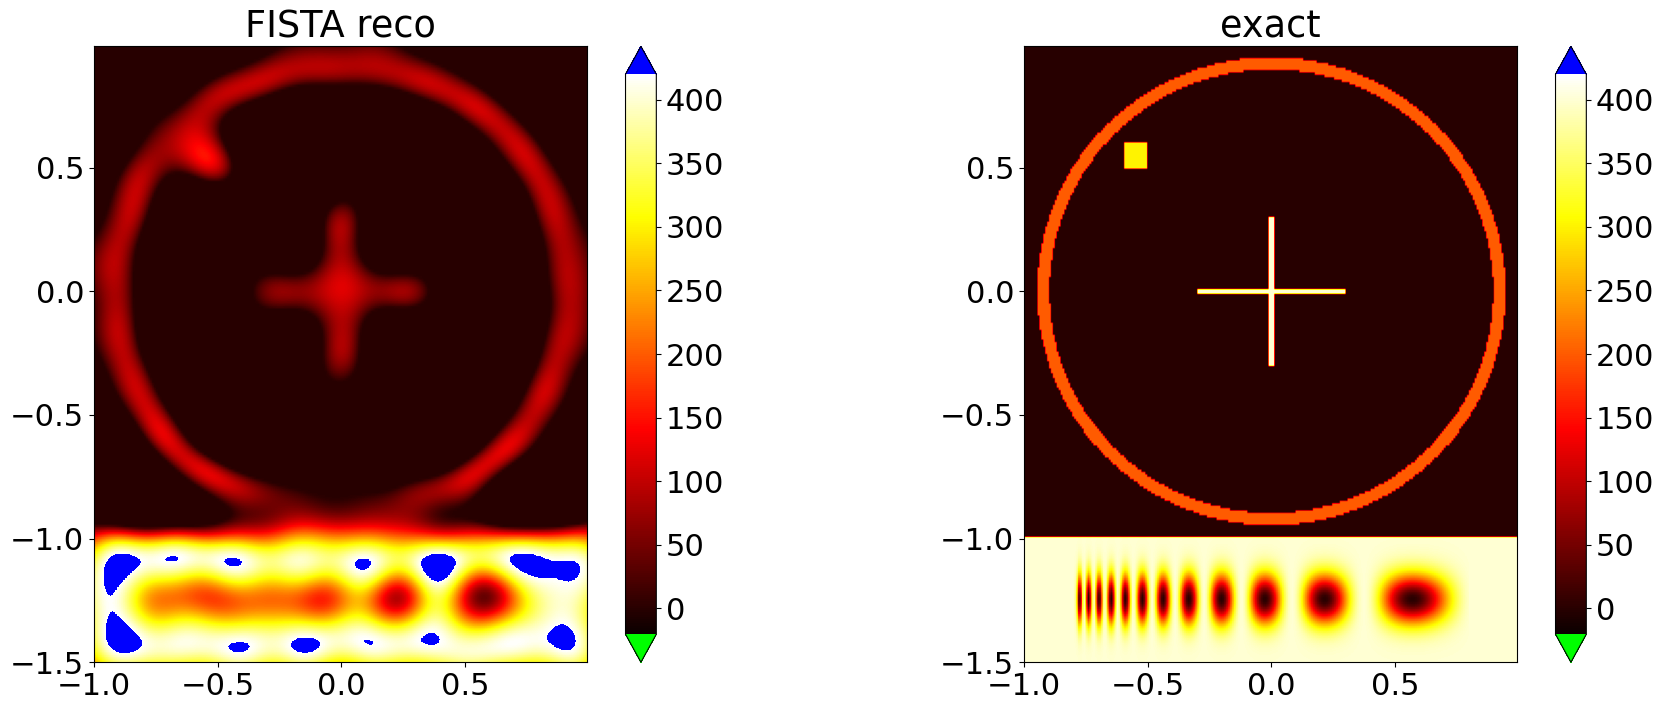

In [ ]:
FISTA_solver_lb = FISTA(settingLower)
stop_FISTA_lb=DualityGapStopping(FISTA_solver_lb,threshold = 1., max_iter=n_iter,logging_level=logging.INFO)
FISTA_solver_lb.run(stoprule=stop_FISTA_lb)
    
comparison_plot(grid,exact_sol,x,title_left='FISTA reco')

2024-07-06 22:10:20,935 INFO PDHG                 :: Using accelerated version 2 with convexity parameters mu_R=1.000e+00, mu_S*=1.000e-03 and ||T||=9.798e-01.
 Expected linear convergence rate: 9.394e-01
2024-07-06 22:10:20,970 INFO PDHG                 :: it. 0: duality gap=3.107e+10
2024-07-06 22:10:20,972 INFO DualityGapStopping   :: it. 0/400: duality gap=3.107e+10
2024-07-06 22:10:20,977 INFO DualityGapStopping   :: it. 0/400: duality gap=3.107e+10
2024-07-06 22:10:21,034 INFO PDHG                 :: it. 1: duality gap=6.823e+07
2024-07-06 22:10:21,035 INFO DualityGapStopping   :: it. 1/400: duality gap=6.823e+07
2024-07-06 22:10:21,103 INFO PDHG                 :: it. 2: duality gap=9.645e+06
2024-07-06 22:10:21,104 INFO DualityGapStopping   :: it. 2/400: duality gap=9.645e+06
2024-07-06 22:10:21,153 INFO PDHG                 :: it. 3: duality gap=1.796e+06
2024-07-06 22:10:21,154 INFO DualityGapStopping   :: it. 3/400: duality gap=1.796e+06
2024-07-06 22:10:21,267 INFO PDHG    

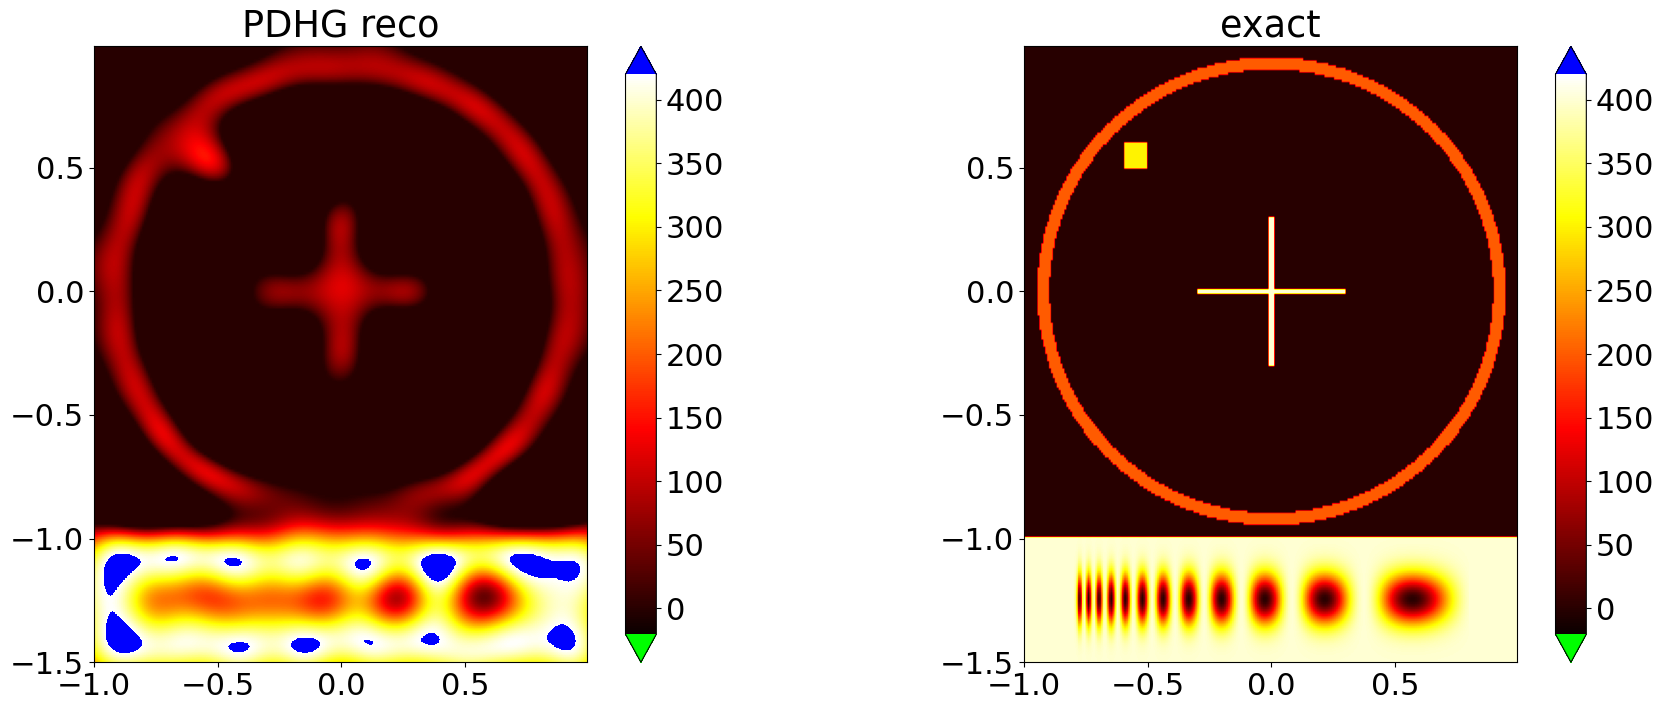

In [ ]:
PDHG_solver_lb = PDHG(settingLower)
stop_PDHG_lb=DualityGapStopping(PDHG_solver_lb,threshold = 1., max_iter=n_iter,logging_level=logging.INFO)
PDHG_solver_lb.run(stoprule=stop_PDHG_lb)

comparison_plot(grid,exact_sol,x, title_left='PDHG reco')

Text(0.5, 1.0, 'convergence for nonnegativity constraint')

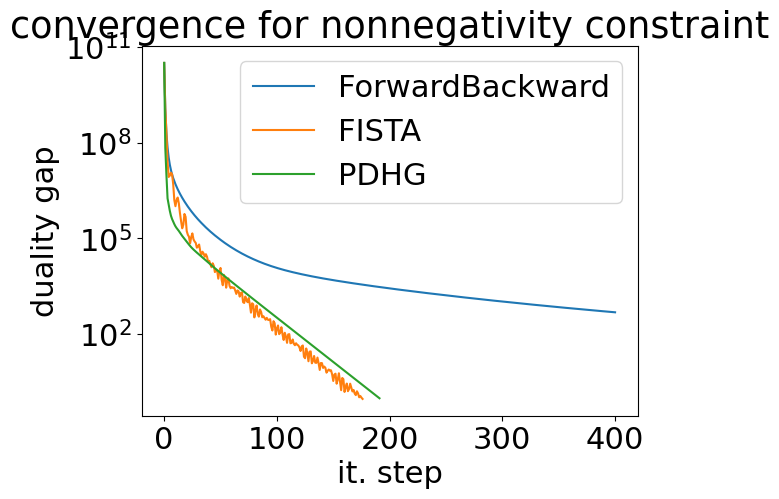

In [ ]:
plt.semilogy(stop_FB_lb.gap_stat,label='ForwardBackward')
plt.semilogy(stop_FISTA_lb.gap_stat,label='FISTA')
plt.semilogy(stop_PDHG_lb.gap_stat,label='PDHG')
plt.legend()
plt.xlabel('it. step'); plt.ylabel('duality gap')
plt.title('convergence for nonnegativity constraint')

# Reconstructions for bilateral constraints

### define setting

In [ ]:
pen = QuadraticBilateralConstraints(grid,lb=0, ub=400,eps=1e-14)
alpha = 1e-4
n_iter = 1000 
settingBilateral = TikhonovRegularizationSetting(op=conv, penalty=pen, data_fid = weighted_data_space,data_fid_shift=data,regpar=alpha)

### Forward-backward splitting

2024-07-06 22:10:36,572 INFO ForwardBackwardSplitting :: initial duality gap: 1.511e+09
2024-07-06 22:10:36,625 INFO ForwardBackwardSplitting :: it.1: duality gap=1.144e+09
2024-07-06 22:10:36,672 INFO ForwardBackwardSplitting :: it.2: duality gap=1.063e+09
2024-07-06 22:10:36,711 INFO ForwardBackwardSplitting :: it.3: duality gap=9.910e+08
2024-07-06 22:10:36,778 INFO ForwardBackwardSplitting :: it.4: duality gap=9.281e+08
2024-07-06 22:10:36,848 INFO ForwardBackwardSplitting :: it.5: duality gap=8.749e+08
2024-07-06 22:10:36,899 INFO ForwardBackwardSplitting :: it.6: duality gap=8.291e+08
2024-07-06 22:10:36,948 INFO ForwardBackwardSplitting :: it.7: duality gap=7.890e+08
2024-07-06 22:10:37,013 INFO ForwardBackwardSplitting :: it.8: duality gap=7.537e+08
2024-07-06 22:10:37,321 INFO ForwardBackwardSplitting :: it.9: duality gap=7.221e+08
2024-07-06 22:10:37,402 INFO ForwardBackwardSplitting :: it.10: duality gap=6.937e+08
2024-07-06 22:10:37,463 INFO ForwardBackwardSplitting :: it.1

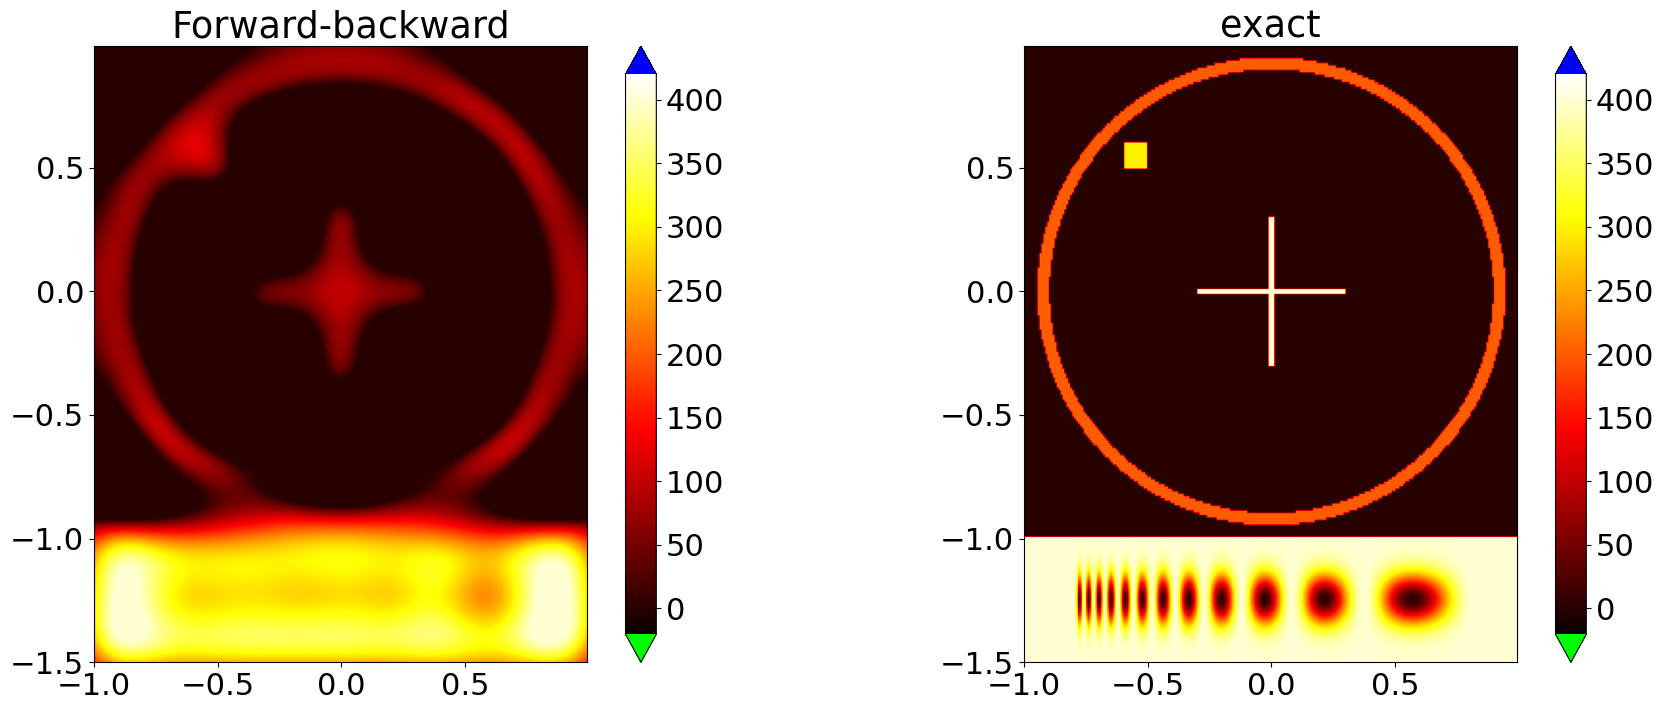

In [ ]:
FB_solver_bil = ForwardBackwardSplitting(settingBilateral)
stop_FB_bil = DualityGapStopping(FB_solver_bil,threshold = 1., max_iter=n_iter,logging_level=logging.INFO)
FB_solver_bil.run(stoprule=stop_FB_bil)

comparison_plot(grid,exact_sol,x,title_left='Forward-backward')

2024-07-06 22:11:30,094 INFO FISTA                :: Setting up FISTA with convexity parameters mu_R=1.000e-06, mu_S=0.000e+00 and step length tau=2.193e+00.
 Expected linear convergence rate: 9.985e-01
2024-07-06 22:11:30,133 INFO FISTA                :: initial duality gap: 1.511e+09
2024-07-06 22:11:30,185 INFO FISTA                :: it.1: duality gap=1.144e+09
2024-07-06 22:11:30,223 INFO FISTA                :: it.2: duality gap=1.063e+09
2024-07-06 22:11:30,289 INFO FISTA                :: it.3: duality gap=9.659e+08
2024-07-06 22:11:30,347 INFO FISTA                :: it.4: duality gap=8.672e+08
2024-07-06 22:11:30,408 INFO FISTA                :: it.5: duality gap=7.767e+08
2024-07-06 22:11:30,456 INFO FISTA                :: it.6: duality gap=6.962e+08
2024-07-06 22:11:30,501 INFO FISTA                :: it.7: duality gap=6.253e+08
2024-07-06 22:11:30,541 INFO FISTA                :: it.8: duality gap=5.629e+08
2024-07-06 22:11:30,585 INFO FISTA                :: it.9: dualit

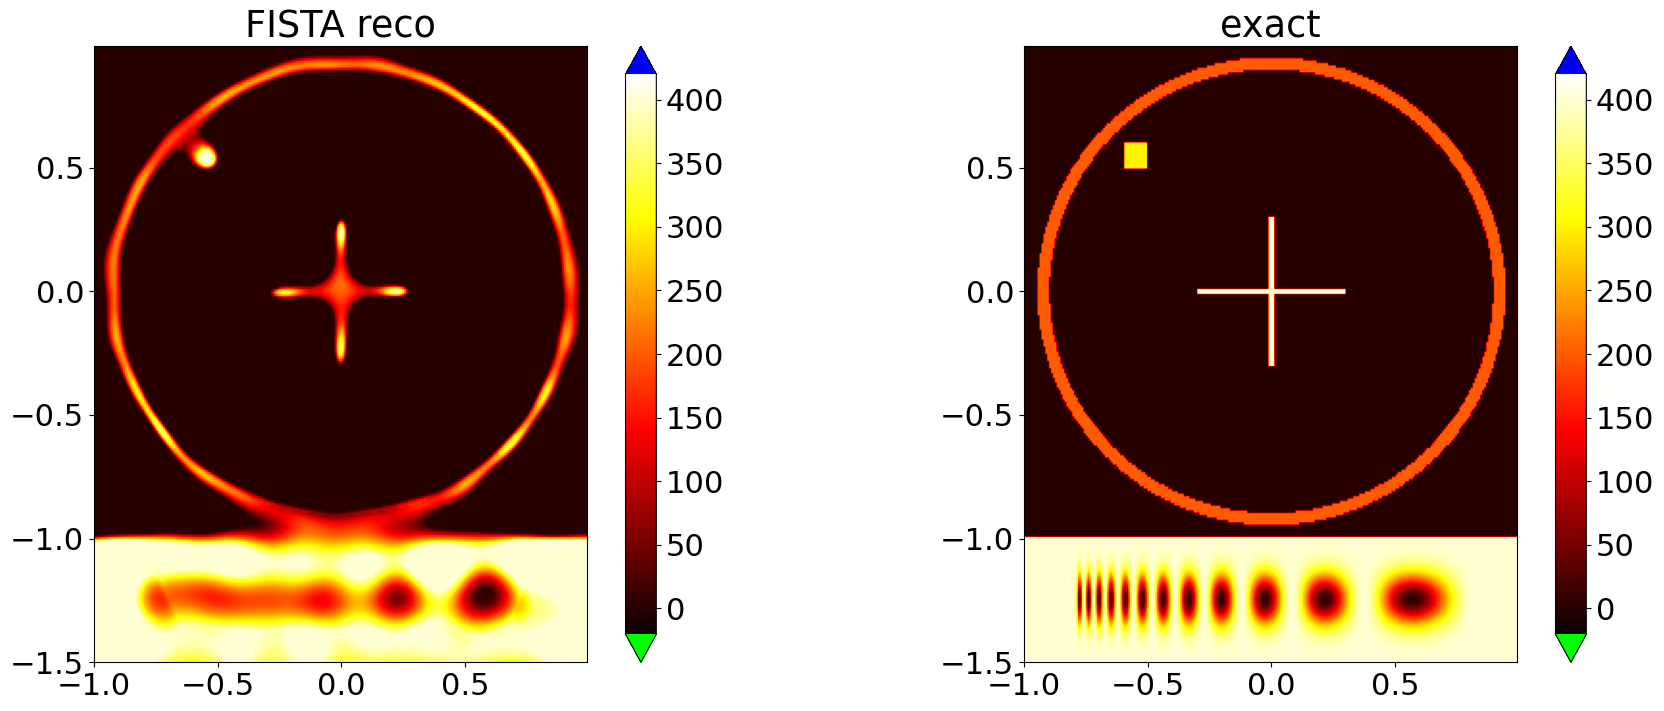

In [ ]:
FISTA_solver_bil = FISTA(settingBilateral)
stop_FISTA_bil = DualityGapStopping(FISTA_solver_bil,threshold = 1., max_iter=n_iter,logging_level=logging.INFO)
gap_FISTA_bil = np.zeros((stoprule.max_iterations+1,))
gap_FISTA_bil[0] = FISTA_solver_bil.gap
for step_nr, (x,y)  in enumerate(FISTA_solver_bil.while_(stoprule)):
    gap_FISTA_bil[step_nr+1] = FISTA_solver_bil.gap
comparison_plot(grid,exact_sol,x,title_left='FISTA reco')

### Primal-dual hybrid gradient (Chambolle-Pock) methods

2024-07-06 22:12:16,126 INFO PDHG                 :: Using accelerated version 2 with convexity parameters mu_R=1.000e+00, mu_S*=1.000e-06 and ||T||=6.753e-01.
 Expected linear convergence rate: 9.970e-01
2024-07-06 22:12:16,157 INFO PDHG                 :: it. 0: duality gap=1.511e+09
2024-07-06 22:12:16,199 INFO PDHG                 :: it. 1: duality gap=1.822e+08
2024-07-06 22:12:16,239 INFO PDHG                 :: it. 2: duality gap=1.766e+08
2024-07-06 22:12:16,283 INFO PDHG                 :: it. 3: duality gap=1.676e+08
2024-07-06 22:12:16,327 INFO PDHG                 :: it. 4: duality gap=1.564e+08
2024-07-06 22:12:16,371 INFO PDHG                 :: it. 5: duality gap=1.444e+08
2024-07-06 22:12:16,409 INFO PDHG                 :: it. 6: duality gap=1.323e+08
2024-07-06 22:12:16,442 INFO PDHG                 :: it. 7: duality gap=1.203e+08
2024-07-06 22:12:16,481 INFO PDHG                 :: it. 8: duality gap=1.087e+08
2024-07-06 22:12:16,527 INFO PDHG                 :: it. 

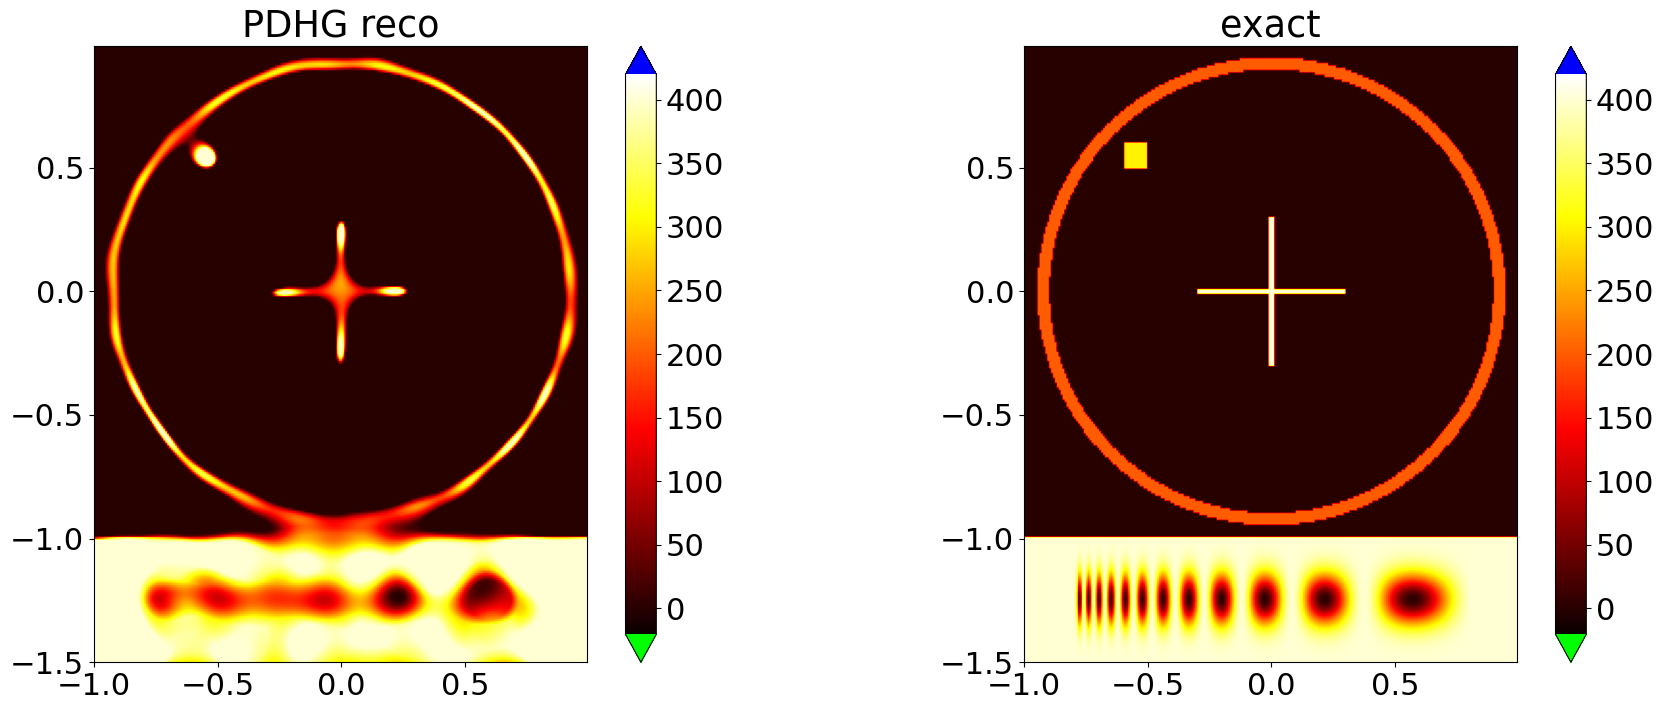

In [ ]:
PDHG_solver_bil = PDHG(settingBilateral)
stop_PDHG_bil = DualityGapStopping(PDHG_solver_bil,threshold = 1., max_iter=n_iter,logging_level=logging.INFO)
PDHG_solver_bil.run(stoprule=PDHG_solver_bil)

comparison_plot(grid,exact_sol,x,title_left='PDHG reco')

Text(0.5, 1.0, 'convergence for bilateral constraints')

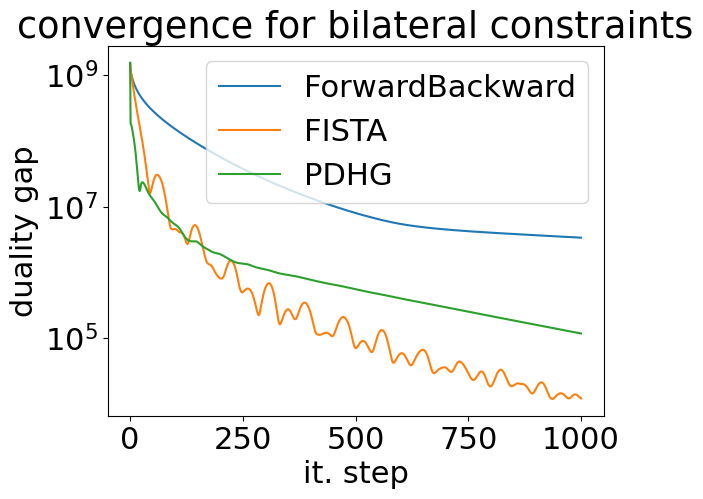

In [ ]:
plt.semilogy(stop_FB_bil.gap_stat,label='ForwardBackward')
plt.semilogy(stop_FISTA_bil.gap_stat,label='FISTA')
plt.semilogy(stop_PDHG_bil.gap_stat,label='PDHG')
plt.legend()
plt.xlabel('it. step'); plt.ylabel('duality gap')
plt.title('convergence for bilateral constraints')